In [2]:

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

Merged frequencies: [0 3]
Merged amplitudes: [4 2]
Maximum sample error: 8.482103908136196e-14


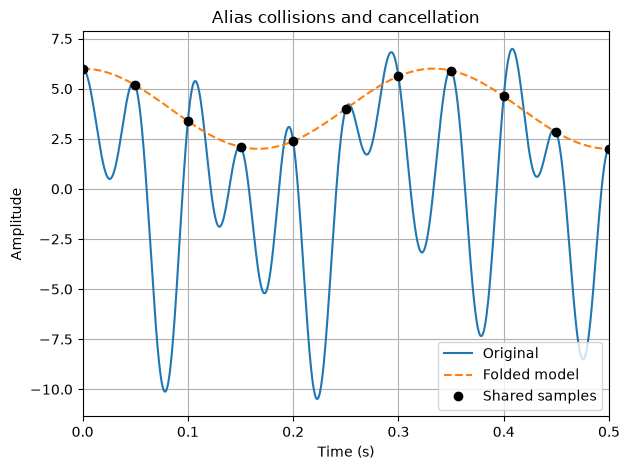

In [3]:
"""Problem 09: When several tones become one.
Hard; 30-minute practice. Read statement.pdf first.
Run this file directly to print results and display the figure.
"""

"""
Background
Consider x(t)=sum A[i] cos(2 pi f[i] t), with zero phase. Under sampling, each cosine folds to an
equivalent frequency in [0,fs/2]. Components landing at the same frequency add their signed
amplitudes. Opposite amplitudes can cancel. A zero-frequency component is a constant (DC).

Your task
Return the folded multitone model after merging collisions and removing groups whose total amplitude
is exactly zero. Then evaluate the original and folded models at the same sample instants and report
their maximum difference. The provided plot displays both continuous models and their samples.

Function contract and assumptions
collapse_tones(freqs, amps, fs) returns (alias_freqs, alias_amps), sorted by ascending frequency.
Use integer frequencies, integer signed amplitudes, and positive even integer fs; duplicate
frequencies are allowed. If all groups cancel, return two empty arrays. evaluate_tones(t, freqs, amps)
returns the signal values at t; an empty model returns zeros. A folding helper is provided.

Example / correctness check
freqs=[3,17,23,7,13,20], amps=[2,1,-1,3,-3,4], fs=20 gives alias_freqs=[0,3], alias_amps=[4,2]. The 7
Hz group cancels; the 3 Hz group sums to 2. With N=40, sample error should be below 1e-10.

Exam instructions
Complete only the TODO functions in template.py and preserve their signatures. The supplied driver
handles printing and plotting. Your functions must work for all valid inputs described above, not just
the example. No external files or packages beyond NumPy and Matplotlib are needed. Small
floating-point differences are acceptable.
"""

def given_alias(f, fs):
    """Provided zero-phase cosine folding rule."""
    r = int(f) % fs
    return min(r, fs-r)

def collapse_tones(freqs, amps, fs):
    # Accumulate signed amplitudes for every folded alias frequency
    alias_map = defaultdict(int)
    for f, a in zip(freqs, amps):
        alias_f = given_alias(f, fs)
        alias_map[alias_f] += int(a)
    
    # Filter out groups whose total amplitude canceled to 0, sorted by frequency
    surviving = sorted((f, a) for f, a in alias_map.items() if a != 0)
    
    if not surviving:
        return np.array([], dtype=int), np.array([], dtype=int)
    
    alias_freqs, alias_amps = zip(*surviving)
    return np.array(alias_freqs, dtype=int), np.array(alias_amps, dtype=int)

def evaluate_tones(t, freqs, amps):
    t = np.asarray(t)
    signal = np.zeros_like(t, dtype=float)
    
    # Empty model returns all zeros
    if len(freqs) == 0:
        return signal
        
    for f, a in zip(freqs, amps):
        signal += a * np.cos(2 * np.pi * f * t)
        
    return signal

if __name__ == "__main__":
    freqs = np.array([3, 17, 23, 7, 13, 20])
    amps = np.array([2, 1, -1, 3, -3, 4])
    fs, N = 20, 40
    alias_freqs, alias_amps = collapse_tones(freqs, amps, fs)
    print("Merged frequencies:", alias_freqs)
    print("Merged amplitudes:", alias_amps)
    t_samples = np.arange(N) / fs
    original_samples = evaluate_tones(t_samples, freqs, amps)
    alias_samples = evaluate_tones(t_samples, alias_freqs, alias_amps)
    print("Maximum sample error:", np.max(np.abs(original_samples-alias_samples)))
    t = np.linspace(0, 0.5, 2001)
    plt.plot(t, evaluate_tones(t, freqs, amps), label="Original")
    plt.plot(t, evaluate_tones(t, alias_freqs, alias_amps), "--", label="Folded model")
    plt.plot(t_samples, original_samples, "ko", label="Shared samples")
    plt.xlim(0, 0.5); plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
    plt.title("Alias collisions and cancellation"); plt.legend(); plt.grid(True)
    plt.tight_layout(); plt.show()


This plot is the visual proof that **a digital sampler can be completely blind to high-frequency chaos.**

Notice the black dots: every single dot lands **exactly on both curves at the same time**.

---

**What the Curves Mean**

* **The Blue Curve (Physical Reality):**
This is the true continuous signal made of 6 different tones mixed together ($3, 7, 13, 17, 23,$ and $20\text{ Hz}$). It oscillates violently between $-10.5$ and $+7$.
* **The Black Dots (What the Computer Actually Sees):**
Because the sample rate is $f_s = 20\text{ Hz}$, the system only takes a snapshot every $0.05\text{ seconds}$ ($t = 0, 0.05, 0.10, \dots$). Everything happening between the dots is completely invisible to the digital hardware.
* **The Orange Dashed Curve (The Alias Model):**
This is the simplified folded signal:

$$x_{\text{folded}}(t) = 4 + 2\cos(2\pi \cdot 3 t)$$



A smooth $3\text{ Hz}$ wave centered at $+4$ that oscillates gently between $2$ and $6$.

---

**Why Did the Signal Collapse So Dramatically?**

Between the snapshots, two things happened at the exact moments the dots were recorded:

1. **Destructive Cancellation:** The $7\text{ Hz}$ and $13\text{ Hz}$ waves had opposite amplitudes ($+3$ and $-3$). At every single black dot, they landed on opposite values and canceled each other out completely, disappearing from the data.
2. **Constructive Merging:** The $17\text{ Hz}$ and $23\text{ Hz}$ waves folded down directly on top of the $3\text{ Hz}$ wave. Their amplitudes added together ($2 + 1 - 1 = 2$).
3. **DC Shift:** The $20\text{ Hz}$ tone hit its peak of $+4$ at every single sample instant ($4 \cos(2\pi \cdot 20 \cdot \frac{n}{20}) = 4 \cos(2\pi n) = +4$), turning into a constant vertical shift.

If you only feed those black sample points into an algorithm, it is mathematically impossible to determine whether the original signal was the chaotic blue wave or the calm orange wave.

## sinc reconstruct

In [8]:
def sinc_reconstruct(samples, sample_times, query_times, T):
    """Reconstructs a bandlimited continuous signal using Whittaker-Shannon interpolation."""
    samples = np.asarray(samples, dtype=float)
    sample_times = np.asarray(sample_times, dtype=float)
    query_times = np.asarray(query_times, dtype=float)
    
    # Flatten query_times to guarantee a 2D matrix: (#query, #samples)
    q_flat = query_times.ravel()
    
    # np.sinc computes sin(pi * x) / (pi * x), matching the Whittaker-Shannon kernel
    kernels = np.sinc((q_flat[:, None] - sample_times[None, :]) / T)
    
    # Weighted linear combination: (M, N) @ (N,) -> (M,)
    reconstructed = kernels @ samples
    return reconstructed.reshape(query_times.shape)

def plot_sinc(samples, sample_times, query_times, fs, ref_curve=None, label="Sinc reconstruction"):
    """Evaluates and visualizes the sinc interpolation alongside discrete samples."""
    T = 1.0 / fs
    reconstructed = sinc_reconstruct(samples, sample_times, query_times, T)

    plt.figure(figsize=(10, 4.5))
    if ref_curve is not None:
        plt.plot(query_times, ref_curve, "--", color="C1", alpha=0.8, label="Folded reference")
    
    plt.plot(query_times, reconstructed, color="C0", linewidth=1.5, label=label)
    plt.plot(sample_times, samples, "ko", markersize=5, label="Samples")

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title("Whittaker-Shannon Sinc Interpolation")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

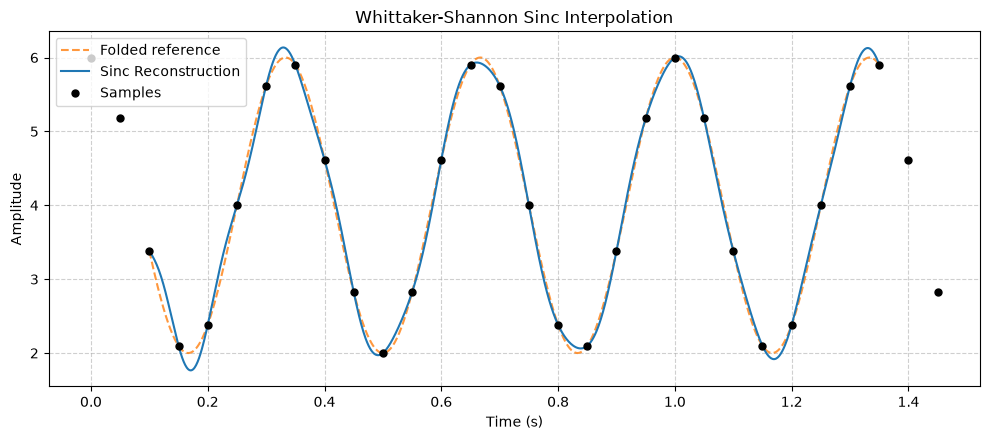

Peak interpolation error away from edges: 3.185e-01


In [9]:
# 1. Setup sampling parameters
fs = 20.0             # Sampling frequency (Hz)
N = 30                # Number of samples
t_samples = np.arange(N) / fs

# 2. Generate samples from the folded model: x(t) = 4 + 2*cos(2*pi*3*t)
samples = 4.0 + 2.0 * np.cos(2 * np.pi * 3.0 * t_samples)

# 3. Dense evaluation grid (stay slightly inside boundaries to avoid edge cutoff)
t_query = np.linspace(t_samples[2], t_samples[-3], 1000)
ref_curve = 4.0 + 2.0 * np.cos(2 * np.pi * 3.0 * t_query)

# 4. Run interpolation and plot
plot_sinc(
    samples=samples,
    sample_times=t_samples,
    query_times=t_query,
    fs=fs,
    ref_curve=ref_curve,
    label="Sinc Reconstruction"
)

# 5. Numerical verification check
reconstructed = sinc_reconstruct(samples, t_samples, t_query, 1.0 / fs)
max_err = np.max(np.abs(reconstructed - ref_curve))
print(f"Peak interpolation error away from edges: {max_err:.3e}")